# MSCS 634 — Lab 1: Data Visualization, Preprocessing & Statistical Analysis

**Name:** Sunny  
**Course:** MSCS 634 — Data Analytics  
**Assignment:** Lab 1 — Data Visualization, Preprocessing & Statistical Analysis  
**Date:** March 14, 2026

---
## Step 1: Data Collection

We use a **Retail Sales Dataset** containing 500 records of sales transactions across categories such as Electronics, Clothing, Home & Kitchen, Sports, and Books. The dataset includes order details, pricing, discounts, customer ratings, and computed revenue.

The dataset was designed with intentional missing values and outliers to practice preprocessing techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the dataset
df = pd.read_csv('sales_data.csv', parse_dates=['Date'])
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (500, 9)


,Order_ID,Date,Category,Region,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Revenue
0,1001,2023-07-31,Clothing,South,61,476.02,0.32,4.4,19745.31
1,1002,2024-08-31,Electronics,North,43,66.49,0.04,2.1,2744.71
2,1003,2024-03-31,Sports,South,42,448.63,0.01,2.9,18654.04
3,1004,2023-11-30,Home & Kitchen,West,25,299.41,0.20,2.8,5988.20
4,1005,2023-08-31,Sports,West,39,310.22,0.16,1.9,10162.81


**Screenshot Required ✅**: The first five rows of the dataset are displayed above.

---
## Step 2: Data Visualization

We create multiple visualizations to explore patterns, relationships, and distributions in the dataset.

### 2.1 Scatter Plot — Units Sold vs. Revenue

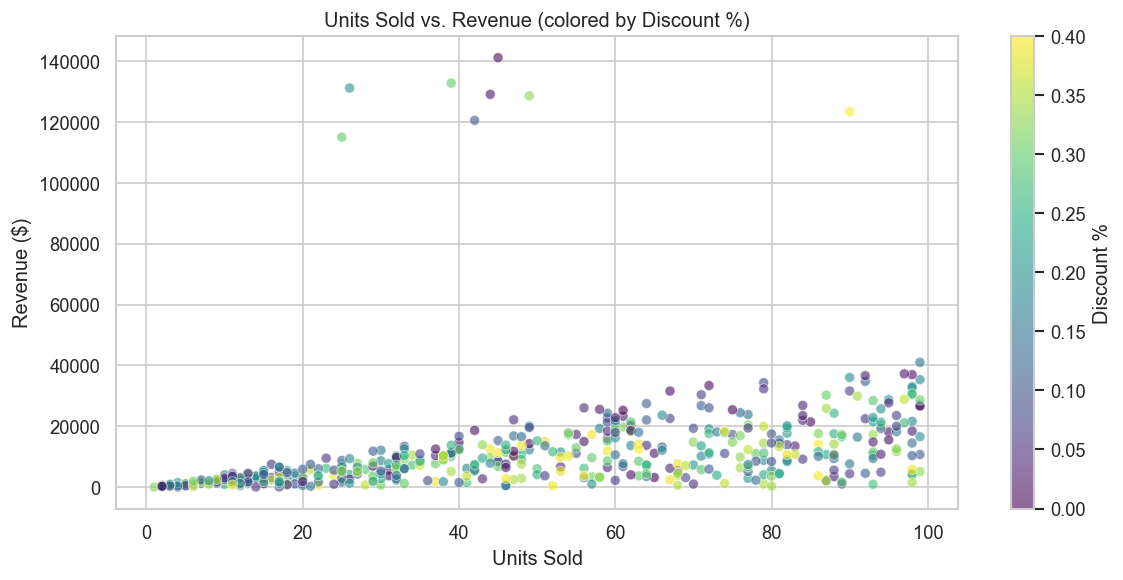

In [3]:
plt.figure(figsize=(10, 5))
scatter = plt.scatter(df['Units_Sold'], df['Revenue'],
                      c=df['Discount_Pct'], cmap='viridis', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.colorbar(scatter, label='Discount %')
plt.xlabel('Units Sold')
plt.ylabel('Revenue ($)')
plt.title('Units Sold vs. Revenue (colored by Discount %)')
plt.tight_layout()
plt.show()

**Insight:** There is a general positive trend between units sold and revenue, as expected. However, some data points show disproportionately high revenue — these are the injected outliers. Higher discounts (darker colors) tend to correspond with lower revenue for similar unit counts.

### 2.2 Line Plot — Monthly Revenue Trend

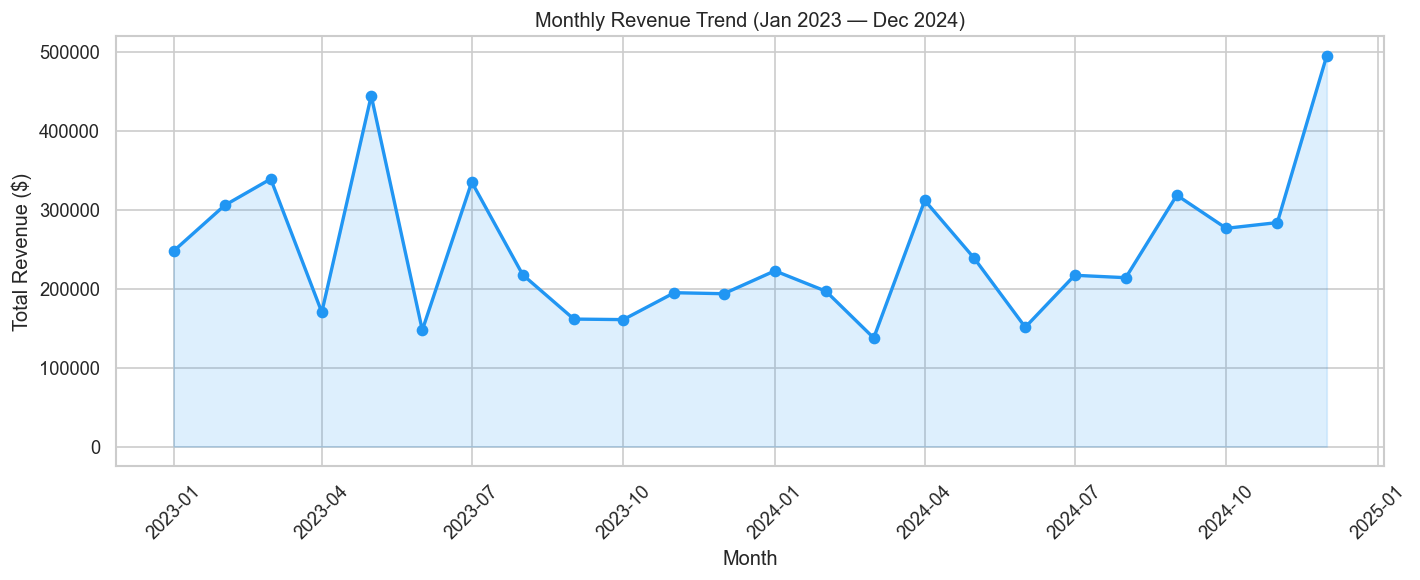

In [4]:
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly_revenue['Date'] = monthly_revenue['Date'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Date'], monthly_revenue['Revenue'], marker='o', color='#2196F3', linewidth=2)
plt.fill_between(monthly_revenue['Date'], monthly_revenue['Revenue'], alpha=0.15, color='#2196F3')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.title('Monthly Revenue Trend (Jan 2023 — Dec 2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Revenue fluctuates across months with no strong seasonal pattern in this synthetic dataset. Some months show spikes due to the presence of high-revenue outlier transactions.

### 2.3 Bar Chart — Average Revenue by Category

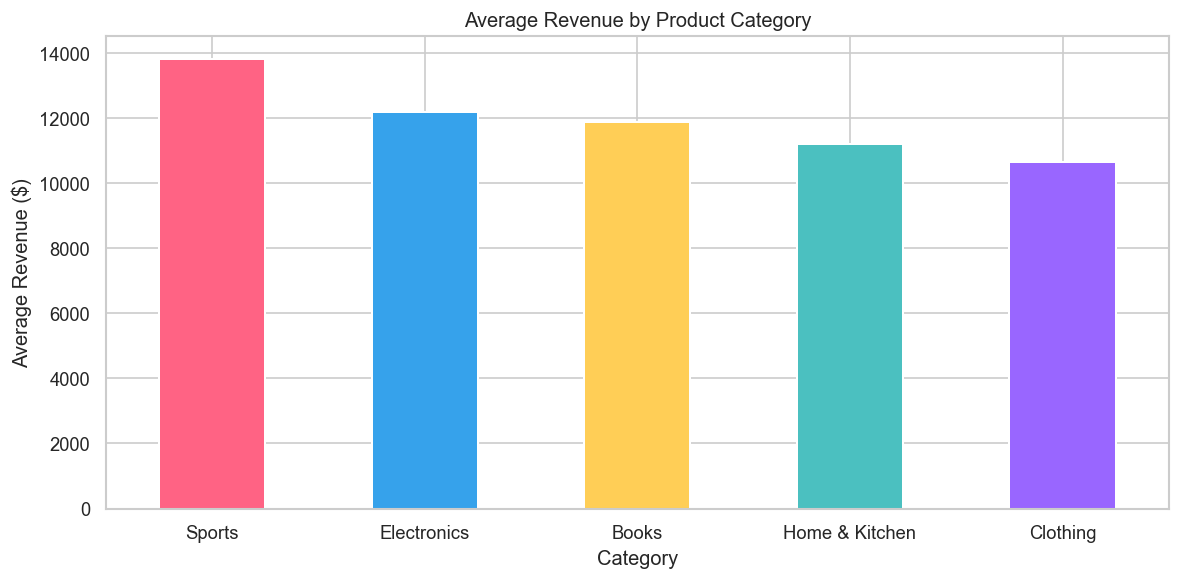

In [5]:
cat_revenue = df.groupby('Category')['Revenue'].mean().sort_values(ascending=False)

colors = ['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF']
plt.figure(figsize=(10, 5))
cat_revenue.plot(kind='bar', color=colors, edgecolor='white', linewidth=1.2)
plt.ylabel('Average Revenue ($)')
plt.title('Average Revenue by Product Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Categories differ in average revenue, reflecting variations in unit price and sales volumes. High-value categories like Electronics tend to generate higher per-order revenue.

### 2.4 Histogram — Distribution of Customer Ratings

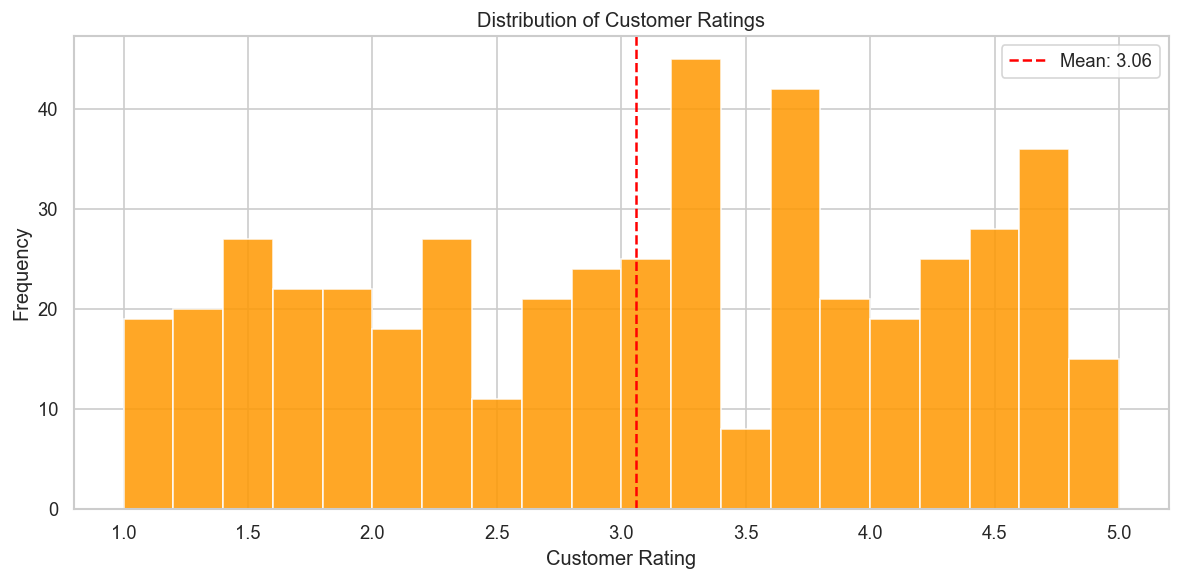

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df['Customer_Rating'].dropna(), bins=20, color='#FF9800', edgecolor='white', alpha=0.85)
plt.axvline(df['Customer_Rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['Customer_Rating'].mean():.2f}")
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Ratings')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Customer ratings are roughly uniformly distributed between 1 and 5, indicating no strong bias toward high or low ratings in this dataset.

### 2.5 Box Plot — Revenue Distribution by Region

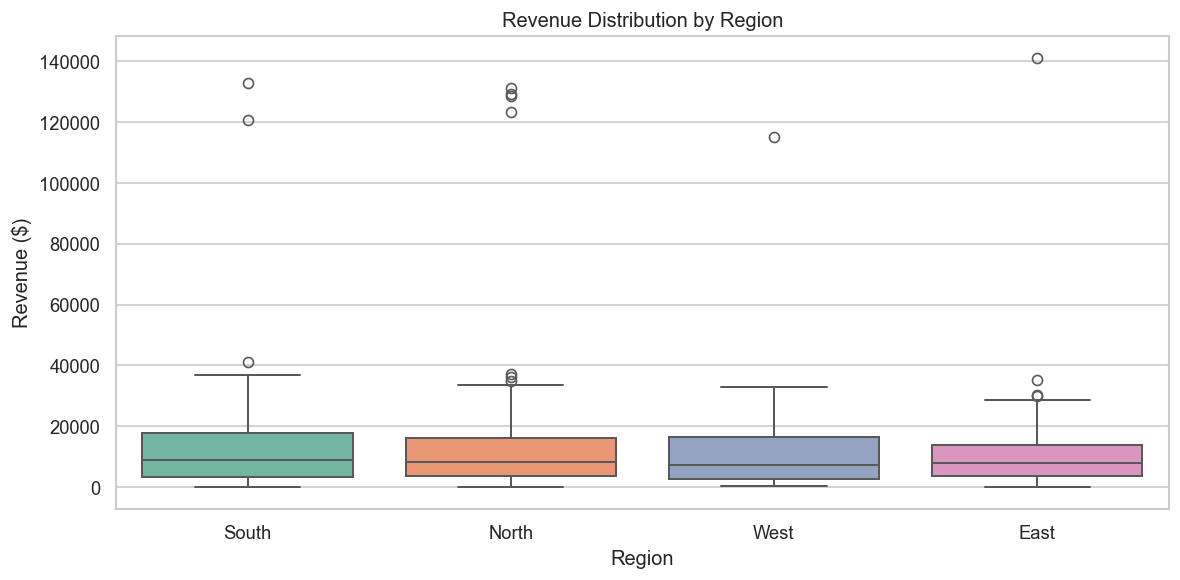

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Region', y='Revenue', data=df.dropna(subset=['Region']),
            palette='Set2', linewidth=1.2)
plt.title('Revenue Distribution by Region')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

**Insight:** The box plots reveal several outlier transactions across regions. The median revenue is fairly similar across regions, suggesting geographic region alone does not strongly drive revenue differences.

### 2.6 Pie Chart — Sales Volume by Category

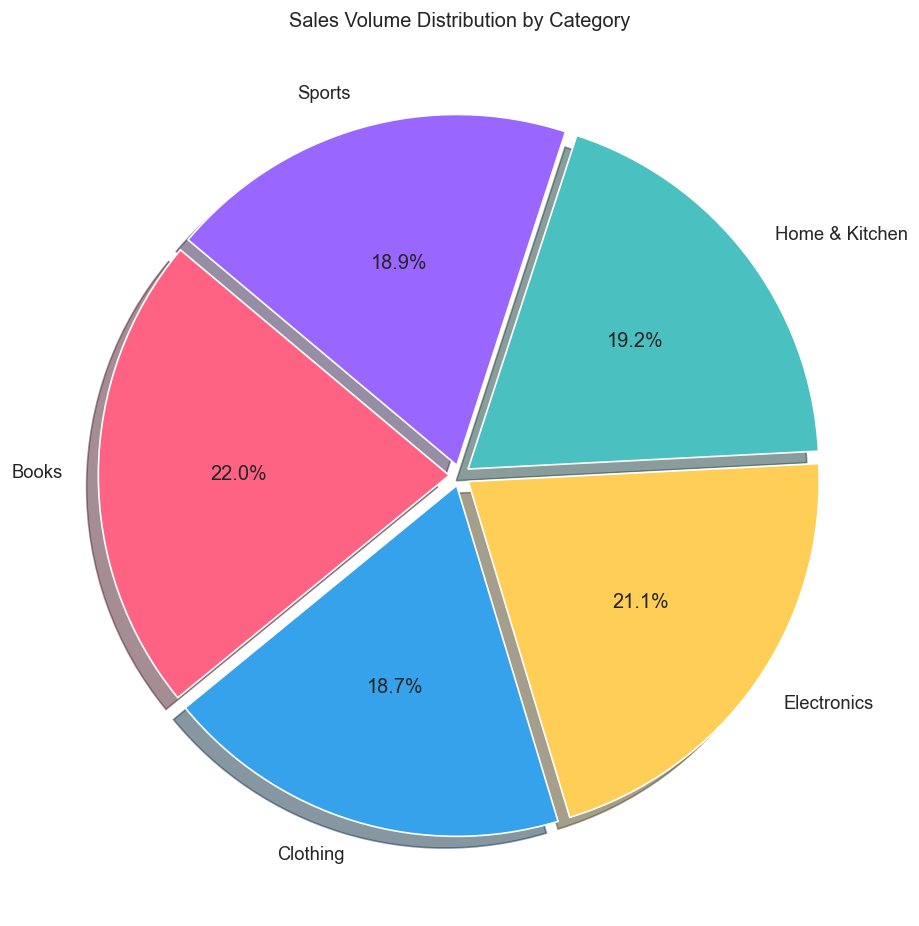

In [8]:
cat_units = df.groupby('Category')['Units_Sold'].sum()

plt.figure(figsize=(8, 8))
plt.pie(cat_units, labels=cat_units.index, autopct='%1.1f%%',
        colors=['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF'],
        startangle=140, explode=[0.03]*5, shadow=True)
plt.title('Sales Volume Distribution by Category')
plt.tight_layout()
plt.show()

**Insight:** The sales volume is distributed relatively evenly among the five categories. No single category overwhelmingly dominates total unit sales.

---
## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

In [9]:
# Detect missing values
print('=== Missing Values per Column ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values per Column ===
Order_ID            0
Date                0
Category            0
Region             10
Units_Sold          0
Unit_Price          0
Discount_Pct       15
Customer_Rating    25
Revenue             0
dtype: int64

Total missing values: 50


In [10]:
# Show rows with missing values (sample)
print('=== Sample Rows with Missing Values ===')
df[df.isnull().any(axis=1)].head(10)

=== Sample Rows with Missing Values ===


,Order_ID,Date,Category,Region,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Revenue
10,1011,2023-11-30,Electronics,North,98,392.79,0.14,NaN,33104.34
17,1018,2024-10-31,Electronics,North,17,243.05,0.21,NaN,3264.16
19,1020,2023-02-28,Clothing,NaN,57,86.18,0.31,1.7,3389.46
25,1026,2023-01-31,Clothing,West,88,309.79,NaN,3.7,24535.37
30,1031,2023-10-31,Electronics,South,81,219.66,0.13,NaN,15479.44
36,1037,2024-11-30,Clothing,South,82,273.53,0.21,NaN,17719.27
55,1056,2023-12-31,Home & Kitchen,East,79,19.55,0.35,NaN,1003.89
59,1060,2024-02-29,Clothing,South,72,397.51,0.09,NaN,26044.86
76,1077,2024-02-29,Sports,East,45,221.40,0.14,NaN,8568.18
77,1078,2024-04-30,Sports,NaN,98,53.21,0.17,1.3,4328.10


In [11]:
# Store copy before cleaning
df_before_missing = df.copy()

# Fill Customer_Rating missing values with the column median
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].median())

# Fill Discount_Pct missing values with the column mean
df['Discount_Pct'] = df['Discount_Pct'].fillna(df['Discount_Pct'].mean())

# Fill Region missing values with the mode (most frequent region)
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])

print('=== Missing Values after Handling ===')
print(df.isnull().sum())

=== Missing Values after Handling ===
Order_ID           0
Date               0
Category           0
Region             0
Units_Sold         0
Unit_Price         0
Discount_Pct       0
Customer_Rating    0
Revenue            0
dtype: int64


In [12]:
# Before vs. After comparison
print('=== BEFORE Handling Missing Values ===')
print(df_before_missing.isnull().sum())
print(f'\n=== AFTER Handling Missing Values ===')
print(df.isnull().sum())

=== BEFORE Handling Missing Values ===
Order_ID            0
Date                0
Category            0
Region             10
Units_Sold          0
Unit_Price          0
Discount_Pct       15
Customer_Rating    25
Revenue             0
dtype: int64

=== AFTER Handling Missing Values ===
Order_ID           0
Date               0
Category           0
Region             0
Units_Sold         0
Unit_Price         0
Discount_Pct       0
Customer_Rating    0
Revenue            0
dtype: int64


**Screenshot Required ✅**: The dataset before and after handling missing values is shown above.  
- `Customer_Rating`: Filled with the **median** (robust to outliers).  
- `Discount_Pct`: Filled with the **mean** (suitable for continuous data).  
- `Region`: Filled with the **mode** (most frequent category).

### 3.2 Outlier Detection and Removal (IQR Method)

In [13]:
# IQR calculation for Revenue
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:.2f}')
print(f'Q3: {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'Lower Bound: {lower_bound:.2f}')
print(f'Upper Bound: {upper_bound:.2f}')

Q1: 3165.39
Q3: 15249.76
IQR: 12084.37
Lower Bound: -14961.17
Upper Bound: 33376.32


In [14]:
# Identify outliers
outliers = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]
print(f'Number of outliers detected: {len(outliers)}')
print('\n=== Outlier Rows ===')
outliers[['Order_ID', 'Category', 'Units_Sold', 'Unit_Price', 'Revenue']]

Number of outliers detected: 17

=== Outlier Rows ===


,Order_ID,Category,Units_Sold,Unit_Price,Revenue
50,1051,Electronics,26,385.02,131117.44
90,1091,Sports,25,201.35,114997.13
182,1183,Books,99,435.11,35322.23
199,1200,Sports,98,380.88,36952.98
203,1204,Home & Kitchen,92,424.35,34745.78
210,1211,Sports,42,240.96,120494.48
220,1221,Clothing,79,477.56,34331.79
281,1282,Books,39,107.06,132743.05
330,1331,Home & Kitchen,90,207.69,123342.09
339,1340,Electronics,99,487.21,40998.72


In [15]:
# Remove outliers
df_before_outlier = df.copy()
df = df[(df['Revenue'] >= lower_bound) & (df['Revenue'] <= upper_bound)]

print(f'Shape before outlier removal: {df_before_outlier.shape}')
print(f'Shape after outlier removal:  {df.shape}')
print(f'Rows removed: {len(df_before_outlier) - len(df)}')

Shape before outlier removal: (500, 9)
Shape after outlier removal:  (483, 9)
Rows removed: 17


**Screenshot Required ✅**: IQR calculations, identified outliers, and the dataset shape before/after removal are shown above.

### 3.3 Data Reduction

In [16]:
# Before data reduction
print(f'=== BEFORE Data Reduction ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

=== BEFORE Data Reduction ===
Shape: (483, 9)
Columns: ['Order_ID', 'Date', 'Category', 'Region', 'Units_Sold', 'Unit_Price', 'Discount_Pct', 'Customer_Rating', 'Revenue']


In [17]:
# Drop less relevant column: Order_ID (unique identifier, not useful for analysis)
df_reduced = df.drop(columns=['Order_ID'])

# Sampling: take a 60% random sample
df_sampled = df_reduced.sample(frac=0.6, random_state=42)

print(f'\n=== AFTER Data Reduction ===')
print(f'After dropping Order_ID — Shape: {df_reduced.shape}')
print(f'After 60% sampling   — Shape: {df_sampled.shape}')
print(f'Remaining columns: {list(df_sampled.columns)}')


=== AFTER Data Reduction ===
After dropping Order_ID — Shape: (483, 8)
After 60% sampling   — Shape: (290, 8)
Remaining columns: ['Date', 'Category', 'Region', 'Units_Sold', 'Unit_Price', 'Discount_Pct', 'Customer_Rating', 'Revenue']


In [18]:
# Use reduced dataset for rest of analysis
df_clean = df_reduced.copy()
print('Using full reduced dataset (without Order_ID) for remaining analysis.')
df_clean.head()

Using full reduced dataset (without Order_ID) for remaining analysis.


,Date,Category,Region,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Revenue
0,2023-07-31,Clothing,South,61,476.02,0.32,4.4,19745.31
1,2024-08-31,Electronics,North,43,66.49,0.04,2.1,2744.71
2,2024-03-31,Sports,South,42,448.63,0.01,2.9,18654.04
3,2023-11-30,Home & Kitchen,West,25,299.41,0.20,2.8,5988.20
4,2023-08-31,Sports,West,39,310.22,0.16,1.9,10162.81


**Screenshot Required ✅**: Dataset shape before and after data reduction is shown above. `Order_ID` was dropped as a non-analytical column, and 60% sampling was demonstrated.

### 3.4 Data Scaling and Discretization

In [19]:
# Before scaling
print('=== BEFORE Scaling ===')
df_clean[['Units_Sold', 'Unit_Price', 'Revenue']].describe().round(2)

=== BEFORE Scaling ===


,Units_Sold,Unit_Price,Revenue
count,483.00,483.00,483.00
mean,50.12,245.94,9583.40
std,28.91,133.47,7889.27
min,1.00,5.16,35.61
25%,25.00,130.13,3099.45
50%,49.00,250.25,7499.83
75%,76.00,338.10,14209.54
max,99.00,497.76,33104.34


In [20]:
# Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = ['Units_Sold', 'Unit_Price', 'Revenue']
df_scaled = df_clean.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print('=== AFTER Min-Max Scaling ===')
df_scaled[cols_to_scale].describe().round(4)

=== AFTER Min-Max Scaling ===


,Units_Sold,Unit_Price,Revenue
count,483.0000,483.0000,483.0000
mean,0.5013,0.4888,0.2887
std,0.2950,0.2709,0.2386
min,0.0000,0.0000,0.0000
25%,0.2449,0.2537,0.0927
50%,0.4898,0.4975,0.2257
75%,0.7653,0.6759,0.4286
max,1.0000,1.0000,1.0000


In [21]:
# Z-Score Standardization
from sklearn.preprocessing import StandardScaler

z_scaler = StandardScaler()
df_zscore = df_clean.copy()
df_zscore[cols_to_scale] = z_scaler.fit_transform(df_clean[cols_to_scale])

print('=== AFTER Z-Score Standardization ===')
df_zscore[cols_to_scale].describe().round(4)

=== AFTER Z-Score Standardization ===


,Units_Sold,Unit_Price,Revenue
count,483.0000,483.0000,483.0000
mean,0.0000,0.0000,-0.0000
std,1.0010,1.0010,1.0010
min,-1.7011,-1.8059,-1.2115
25%,-0.8700,-0.8686,-0.8227
50%,-0.0389,0.0323,-0.2644
75%,0.8960,0.6912,0.5870
max,1.6925,1.8887,2.9845


In [22]:
# Discretization: Convert Customer_Rating into categories
print('=== Discretization: Customer_Rating → Rating_Category ===')
df_clean['Rating_Category'] = pd.cut(
    df_clean['Customer_Rating'],
    bins=[0, 2, 3.5, 5],
    labels=['Low', 'Medium', 'High']
)
print(df_clean['Rating_Category'].value_counts())
print()
df_clean[['Customer_Rating', 'Rating_Category']].head(10)

=== Discretization: Customer_Rating → Rating_Category ===
Rating_Category
Medium    190
High      180
Low       113
Name: count, dtype: int64



,Customer_Rating,Rating_Category
0,4.4,High
1,2.1,Medium
2,2.9,Medium
3,2.8,Medium
4,1.9,Low
5,2.6,Medium
6,1.2,Low
7,2.1,Medium
8,4.3,High
9,2.1,Medium


**Screenshot Required ✅**: Data before and after scaling (Min-Max and Z-Score) is shown, along with discretization of `Customer_Rating` into Low / Medium / High categories.

---
## Step 4: Statistical Analysis

### 4.1 General Overview of Data

In [23]:
print('=== Dataset Info ===')
df_clean.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 483 entries, 0 to 497
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             483 non-null    datetime64[ns]
 1   Category         483 non-null    object        
 2   Region           483 non-null    object        
 3   Units_Sold       483 non-null    int64         
 4   Unit_Price       483 non-null    float64       
 5   Discount_Pct     483 non-null    float64       
 6   Customer_Rating  483 non-null    float64       
 7   Revenue          483 non-null    float64       
 8   Rating_Category  483 non-null    category      
dtypes: category(1), datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 34.6+ KB


In [24]:
print('=== Descriptive Statistics ===')
df_clean.describe().round(2)

=== Descriptive Statistics ===


,Date,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Revenue
count,483,483.00,483.00,483.00,483.00,483.00
mean,2024-01-09 05:13:02.608695552,50.12,245.94,0.20,3.07,9583.40
min,2023-01-31 00:00:00,1.00,5.16,0.00,1.00,35.61
25%,2023-06-30 00:00:00,25.00,130.13,0.09,2.10,3099.45
50%,2023-12-31 00:00:00,49.00,250.25,0.20,3.20,7499.83
75%,2024-07-31 00:00:00,76.00,338.10,0.30,3.95,14209.54
max,2024-12-31 00:00:00,99.00,497.76,0.40,5.00,33104.34
std,NaN,28.91,133.47,0.12,1.12,7889.27


**Screenshot Required ✅**: `.info()` and `.describe()` outputs displayed above.

### 4.2 Central Tendency Measures

In [25]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

central_tendency = pd.DataFrame({
    'Min': df_clean[numeric_cols].min(),
    'Max': df_clean[numeric_cols].max(),
    'Mean': df_clean[numeric_cols].mean(),
    'Median': df_clean[numeric_cols].median(),
    'Mode': df_clean[numeric_cols].mode().iloc[0]
}).round(2)

print('=== Central Tendency Measures ===')
central_tendency

=== Central Tendency Measures ===


,Min,Max,Mean,Median,Mode
Units_Sold,1.00,99.00,50.12,49.00,98.00
Unit_Price,5.16,497.76,245.94,250.25,5.16
Discount_Pct,0.00,0.40,0.20,0.20,0.30
Customer_Rating,1.00,5.00,3.07,3.20,3.20
Revenue,35.61,33104.34,9583.40,7499.83,11007.11


**Screenshot Required ✅**: Min, Max, Mean, Median, and Mode for all numeric columns.

### 4.3 Dispersion Measures

In [26]:
dispersion = pd.DataFrame({
    'Range': df_clean[numeric_cols].max() - df_clean[numeric_cols].min(),
    'Q1 (25%)': df_clean[numeric_cols].quantile(0.25),
    'Q2 (50%)': df_clean[numeric_cols].quantile(0.50),
    'Q3 (75%)': df_clean[numeric_cols].quantile(0.75),
    'IQR': df_clean[numeric_cols].quantile(0.75) - df_clean[numeric_cols].quantile(0.25),
    'Variance': df_clean[numeric_cols].var(),
    'Std Dev': df_clean[numeric_cols].std()
}).round(2)

print('=== Dispersion Measures ===')
dispersion

=== Dispersion Measures ===


,Range,Q1 (25%),Q2 (50%),Q3 (75%),IQR,Variance,Std Dev
Units_Sold,98.00,25.00,49.00,76.00,51.00,835.69,28.91
Unit_Price,492.60,130.13,250.25,338.10,207.97,17813.35,133.47
Discount_Pct,0.40,0.09,0.20,0.30,0.21,0.01,0.12
Customer_Rating,4.00,2.10,3.20,3.95,1.85,1.26,1.12
Revenue,33068.73,3099.45,7499.83,14209.54,11110.09,62240619.38,7889.27


**Screenshot Required ✅**: Range, Quartiles, IQR, Variance, and Standard Deviation for all numeric columns.

### 4.4 Correlation Analysis

In [27]:
corr_matrix = df_clean[numeric_cols].corr().round(3)
print('=== Correlation Matrix ===')
corr_matrix

=== Correlation Matrix ===


,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Revenue
Units_Sold,1.000,-0.080,0.003,-0.001,0.622
Unit_Price,-0.080,1.000,0.048,0.017,0.609
Discount_Pct,0.003,0.048,1.000,0.050,-0.146
Customer_Rating,-0.001,0.017,0.050,1.000,-0.002
Revenue,0.622,0.609,-0.146,-0.002,1.000


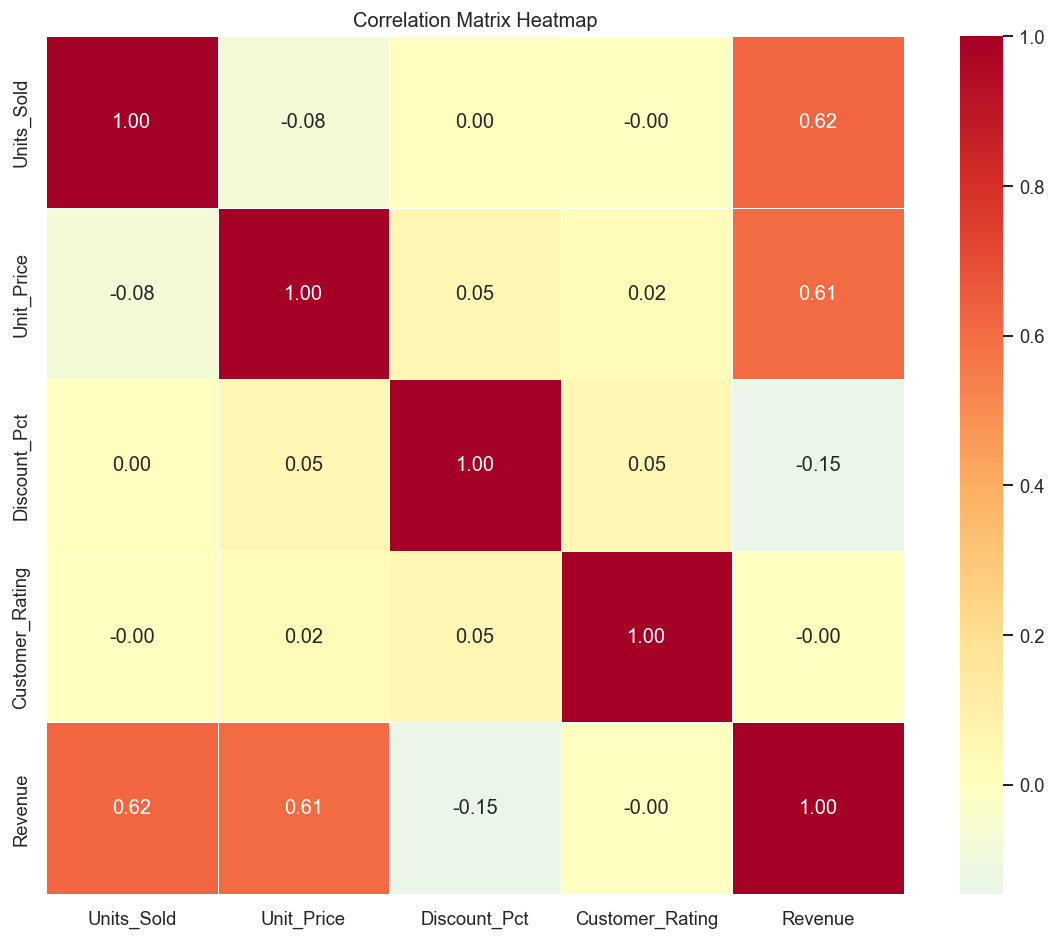

In [28]:
# Heatmap visualization of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

**Screenshot Required ✅**: The correlation matrix and heatmap are displayed above.

**Key Observations:**
- `Units_Sold` and `Revenue` show a moderate positive correlation — more units sold generally means more revenue.
- `Discount_Pct` and `Revenue` show a negative relationship — higher discounts reduce revenue.
- `Customer_Rating` shows very weak correlation with financial metrics, suggesting ratings are independent of transaction amounts.

---
## Summary

This lab applied a complete data analytics pipeline to a retail sales dataset:

1. **Data Collection**: Loaded a 500-record sales dataset with 9 features.
2. **Data Visualization**: Created 6 chart types (scatter, line, bar, histogram, box, pie) revealing revenue patterns and distributions.
3. **Data Preprocessing**: Handled missing values, removed outliers via IQR, reduced dimensions, applied Min-Max and Z-Score scaling, and discretized ratings.
4. **Statistical Analysis**: Computed central tendency, dispersion measures, and a correlation matrix to summarize variable relationships.